In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

from datasets import Dataset
from helpfuncties import load_dataset
from preprocessing import minimal_clean

set_seed(42)

print("CUDA beschikbaar:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA beschikbaar: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


In [3]:
df = load_dataset()
df["Omschrijving"] = df["Omschrijving"].astype(str).apply(minimal_clean)

X = df["Omschrijving"].astype(str)
y = df["Product"]

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(y)

print("Aantal classes:", len(label_encoder.classes_))
print(label_encoder.classes_)

Aantal classes: 6
['Bankrekening' 'Consumentenkrediet' 'Creditcard' 'Hypotheek' 'Incasso'
 'Kredietregistratie']


In [4]:
train_df, temp_df = train_test_split(
    df[["Omschrijving", "label"]],
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

In [5]:
MODEL_NAME = "ProsusAI/finbert"  # inhoudelijk betere keuze dan finbert-tone

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["Omschrijving"],
        truncation=True,
        padding=True,          # dynamic padding
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c.startswith("__index")])
val_ds   = val_ds.remove_columns([c for c in val_ds.column_names if c.startswith("__index")])
test_ds  = test_ds.remove_columns([c for c in test_ds.column_names if c.startswith("__index")])

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

Map: 100%|██████████| 2223/2223 [00:00<00:00, 8083.06 examples/s]


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_),
    ignore_mismatched_sizes=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
training_args = TrainingArguments(
    output_dir="./results_finbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,          # iets ruimer dan 3
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    logging_steps=100,
    report_to="none"
)

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

C:\Users\odess\AppData\Local\Temp\ipykernel_26816\2214961272.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.508500,0.467401,0.853285,0.852223
2,0.476700,0.480378,0.874437,0.874414
3,0.231100,0.574402,0.868137,0.867588
4,0.159400,0.713949,0.862286,0.861720
5,0.131400,0.709943,0.866337,0.866098


TrainOutput(global_step=6485, training_loss=0.3159557438852609, metrics={'train_runtime': 1049.2819, 'train_samples_per_second': 49.42, 'train_steps_per_second': 6.18, 'total_flos': 6822056889031680.0, 'train_loss': 0.3159557438852609, 'epoch': 5.0})

In [12]:
predictions = trainer.predict(test_ds)

y_logits = predictions.predictions
y_true   = predictions.label_ids

y_proba = torch.softmax(torch.tensor(y_logits), dim=1).numpy()
y_pred  = np.argmax(y_proba, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="weighted")
print(f"Accuracy FinBERT: {test_accuracy:.3f}")
print(f"F1 FinBERT: {test_f1:.3f}")

Accuracy FinBERT: 0.873
F1 FinBERT: 0.872


In [13]:
print("Classification Report FinBERT:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Classification Report FinBERT:
                    precision    recall  f1-score   support

      Bankrekening       0.81      0.89      0.85       223
Consumentenkrediet       0.79      0.69      0.74       142
        Creditcard       0.84      0.80      0.82       282
         Hypotheek       0.92      0.96      0.94       497
           Incasso       0.85      0.89      0.87       612
Kredietregistratie       0.93      0.85      0.89       467

          accuracy                           0.87      2223
         macro avg       0.86      0.85      0.85      2223
      weighted avg       0.87      0.87      0.87      2223



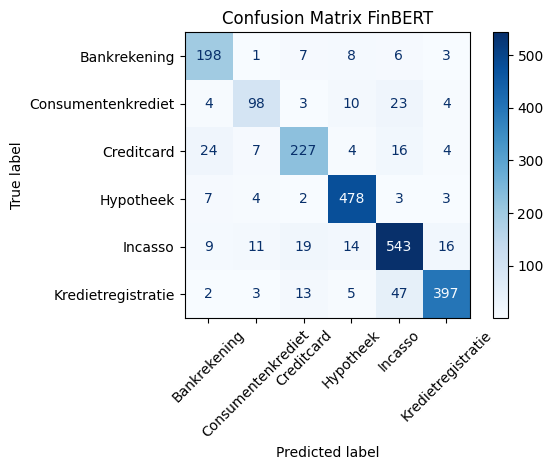

In [18]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.title("Confusion Matrix FinBERT")
plt.tight_layout()
plt.savefig("afbeeldingen/confusion_matrix_FinBERT.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()

In [15]:
auc_finbert = roc_auc_score(
    y_true,
    y_proba,
    multi_class="ovr"
)

print(f"AUC FinBERT: {auc_finbert:.3f}")

AUC FinBERT: 0.977
